In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import mlflow
import matplotlib.pyplot as plt

%matplotlib widget

In [2]:
RUN_ID = '01dc416721fa4bb093b008539b522ba6'

In [3]:
# load mode parameter from data
lure_params_path = 'lure_model_params_scaled.npz'
theta = np.load(lure_params_path)
# print(f'Saved Lur\'e model parameters to {lure_params_path}')
A_fit = theta['A']
B_fit = theta['B']
C_fit = theta['C']
B2_fit = theta['B2']
C2_fit = theta['C2']
D_fit = theta['D']
D12_fit = theta['D12']
D21_fit = theta['D21']
TS = float(theta['TS'])
nz = int(theta['nz'])
nx = int(theta['nx'])
nd = int(theta['nu'])
ne = int(theta['ny'])

In [13]:
B2

array([[-9.19285355e-04,  9.71438939e-04, -3.36456319e-03,
        -2.35166139e-02,  1.34980682e-02,  9.03337556e-03,
         1.12221156e-02, -6.44528897e-03,  9.04928119e-03,
         7.93318601e-03, -2.66771759e-03, -5.42165958e-03,
        -1.35942301e-02, -2.89871448e-03, -9.23959516e-03,
        -4.64464420e-03,  9.55500603e-03,  5.88182946e-05,
        -1.02073188e-02, -3.15003667e-03,  1.30807561e-02,
         1.98738540e-03,  1.66992266e-02, -6.33040298e-04,
         1.71695054e-02, -8.24714924e-03,  7.91176417e-04,
         6.23896311e-03,  3.03160057e-03,  3.75926784e-03,
        -2.00083850e-03, -2.85574856e-03,  3.10981547e-03,
         3.80490323e-03, -3.06682954e-03,  9.04563381e-03,
         1.45347862e-03, -1.18204663e-02, -7.65749982e-03,
         1.29902589e-04],
       [ 3.08972090e-03, -1.14933968e-04, -5.16823379e-03,
        -6.79881610e-03, -1.15463373e-03, -1.15883205e-02,
        -6.89334302e-03, -4.11043822e-03, -1.70931619e-04,
        -2.12200511e-03, -9.89

In [4]:
# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from sysid.data import DataNormalizer
from sysid.models import SimpleLure

# Set MLflow tracking URI (adjust if needed)
mlflow_uri = project_root / "mlruns"
mlflow.set_tracking_uri(f"file://{mlflow_uri}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

# Load model architecture from MLflow (logged at end of training as 'final' model)
print(f"Loading model from run {RUN_ID}...")
model_uri = f"runs:/{RUN_ID}/model"
model = mlflow.pytorch.load_model(model_uri)
print(f"Model loaded: {type(model).__name__}")
print(f"Model parameters: {model.count_parameters():,}")

# Load best model weights (saved whenever validation loss improved during training)
# This overwrites the final model weights with the best checkpoint weights
print("Loading best model weights from checkpoint artifact...")
try:
    best_model_path = mlflow.artifacts.download_artifacts(
        run_id=RUN_ID, artifact_path="models/best_model.pt"
    )
    checkpoint = torch.load(best_model_path, map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    best_epoch = checkpoint.get("best_epoch", "?")
    best_val_loss = checkpoint.get("best_val_loss", "?")
    print(f"Best model weights loaded (best epoch: {best_epoch}, best val loss: {best_val_loss:.6f})")
except Exception as e:
    print(f"Could not load best model weights, using final model: {e}")

# Load normalizer (if it was used during training)
normalizer = None
try:
    normalizer_path = mlflow.artifacts.download_artifacts(
        run_id=RUN_ID, artifact_path="models/normalizer.json"
    )
    normalizer = DataNormalizer.load(normalizer_path)
    print(f"Normalizer loaded from artifacts")
except Exception as e:
    print(f"No normalizer found (data might not be normalized): {e}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
print(f"Device: {device}")

MLflow tracking URI: file:///Users/jack/Documents/01_Git/01_promotion/genSecSysId/python/mlruns
Loading model from run 01dc416721fa4bb093b008539b522ba6...


Model loaded: SimpleLure
Model parameters: 1,852
Loading best model weights from checkpoint artifact...


Best model weights loaded (best epoch: 18, best val loss: 0.103322)


Normalizer loaded from artifacts
Device: cpu


In [5]:
model.delta

tensor(7.2811)

In [6]:
def bmat(blocks):
    """Construct a sparse matrix from blocks."""
    block_rows = []
    for row in blocks:
        block_row = np.hstack(row)
        block_rows.append(block_row)
    return np.vstack(block_rows)

nx, nd, nz, ne = model.nx, model.nd, model.nz, model.ne

A = model.A.cpu().detach().numpy()
B = model.B.cpu().detach().numpy()
B2 = model.B2.cpu().detach().numpy()

C = model.C.cpu().detach().numpy()
D = model.D.cpu().detach().numpy()
D12 = model.D12.cpu().detach().numpy()

C2 = model.C2.cpu().detach().numpy()
D21 = model.D21.cpu().detach().numpy()

tau = model.tau.cpu().detach().numpy()
alpha = 1/(1 + np.exp(-tau))  # Sigmoid of tau
s = model.s.cpu().detach().numpy().reshape((1,1))
P = model.P.cpu().detach().numpy()
L = model.L.cpu().detach().numpy()
la = model.la.cpu().detach().numpy()
M = np.diag(la)
delta = model.delta.cpu().detach().numpy()

F = bmat(
    [
        [-(alpha**2) * P, np.zeros((nx, nd)), P @ C2.T + L.T, P @ A.T],
        [np.zeros((nd, nx)), -np.eye(nd), D21.T, B.T],
        [C2 @ P + L, D21, -2 * M, M @ B2.T],
        [A @ P, B, B2 @ M, -P],
    ]
)
G = []
for i in range(nz):
    li = L[i, :].reshape((1, -1), order="C")
    G_i = bmat([[1/s**2, li], [li.T, P]])
    G.append(G_i)

# sanity check
print('max eigenvalue of F:', np.max(np.real(np.linalg.eig(F)[0])))
for i, G_i in enumerate(G):
    eigvals = np.linalg.eig(G_i)[0]
    min_eigval = np.min(np.real(eigvals))
    print(f"min eigenvalue of G[{i}]: {min_eigval}")


max eigenvalue of F: -0.003394231230332856
min eigenvalue of G[0]: 0.4455342767863509
min eigenvalue of G[1]: 0.4455342767863509
min eigenvalue of G[2]: 0.4455342767863509
min eigenvalue of G[3]: 0.4455342767863509
min eigenvalue of G[4]: 0.4455342767863509
min eigenvalue of G[5]: 0.4455342767863509
min eigenvalue of G[6]: 0.4455342767863509
min eigenvalue of G[7]: 0.4455342767863509
min eigenvalue of G[8]: 0.4455342767863509
min eigenvalue of G[9]: 0.4455342767863509
min eigenvalue of G[10]: 0.4455342767863509
min eigenvalue of G[11]: 0.4455342767863509
min eigenvalue of G[12]: 0.4455342767863509
min eigenvalue of G[13]: 0.4455342767863509
min eigenvalue of G[14]: 0.4455342767863509
min eigenvalue of G[15]: 0.4455342767863509
min eigenvalue of G[16]: 0.4455342767863509
min eigenvalue of G[17]: 0.4455342767863509
min eigenvalue of G[18]: 0.4455342767863509
min eigenvalue of G[19]: 0.4455342767863509
min eigenvalue of G[20]: 0.4455342767863509
min eigenvalue of G[21]: 0.4455342767863509

In [7]:
dzn = model.lure.Delta
B2_t = torch.tensor(B2, dtype=torch.float64)
C2_t = torch.tensor(C2, dtype=torch.float64)
D21_t = torch.tensor(D21, dtype=torch.float64)

B2_t_fitted = torch.tensor(B2_fit, dtype=torch.float64)
C2_t_fitted = torch.tensor(C2_fit, dtype=torch.float64)
D21_t_fitted = torch.tensor(D21_fit, dtype=torch.float64)



In [15]:
D21_t_fitted

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])

In [8]:
def man_nonlinearity_fitted(x, u):
    x_v = torch.tensor([[x] , [0.0]])
    u_v = u.reshape((1, 1))
    z = C2_t_fitted @ x_v + D21_t_fitted @ u_v
    w = dzn(z)
    # print(w)
    return (B2_t_fitted @ w)[1]

In [9]:
def man_nonlinearity(x, u):
    x_v = torch.tensor([[x] , [0.0]])
    u_v = u.reshape((1, 1))
    z = C2_t @ x_v + D21_t @ u_v
    w = dzn(z)
    # print(w)
    return (B2_t @ w)[1]

In [16]:
C2_t

tensor([[ 0.0028, -0.0087],
        [-0.0013,  0.0002],
        [ 0.0067,  0.0151],
        [ 0.0392,  0.0172],
        [-0.0344,  0.0020],
        [-0.0267,  0.0396],
        [-0.0312,  0.0224],
        [ 0.0144,  0.0133],
        [-0.0219, -0.0009],
        [-0.0174,  0.0051],
        [ 0.0044,  0.0268],
        [ 0.0111,  0.0908],
        [ 0.0235, -0.0043],
        [ 0.0070, -0.0162],
        [ 0.0231,  0.0092],
        [ 0.0097,  0.0389],
        [-0.0244, -0.0117],
        [-0.0002, -0.0041],
        [ 0.0211,  0.0152],
        [ 0.0039,  0.0037],
        [-0.0317,  0.0096],
        [-0.0031, -0.0006],
        [-0.0533, -0.0062],
        [ 0.0001,  0.0010],
        [-0.0367,  0.0093],
        [ 0.0192,  0.0100],
        [-0.0008, -0.0112],
        [-0.0100, -0.0110],
        [-0.0054, -0.0006],
        [-0.0050, -0.0137],
        [ 0.0029, -0.0007],
        [ 0.0061, -0.0111],
        [-0.0066, -0.0005],
        [-0.0062, -0.0242],
        [ 0.0061,  0.0068],
        [-0.0242,  0

In [10]:

man_nonlinearity(0.5, np.zeros((1,1)))

tensor([0.])

In [11]:
# Evaluate nonlinearity at a grid of input points
N = 500
xs = np.linspace(-10, 10, N).reshape(N, 1)
us = np.zeros((N, 1))

y_hats = []
y_hats_fitted = []
for xi, ui in zip(xs, us):
    # print(f"xi: {xi}, ui: {ui}")
    y_hats.append(man_nonlinearity(xi[0], ui))  
    y_hats_fitted.append(man_nonlinearity_fitted(xi[0], ui))

# y_hats = [man_nonlinearity(xi[0], ui) for xi, ui in zip(xs, us)]
# y_hats = np.array(y_hats).reshape(-1, 1)


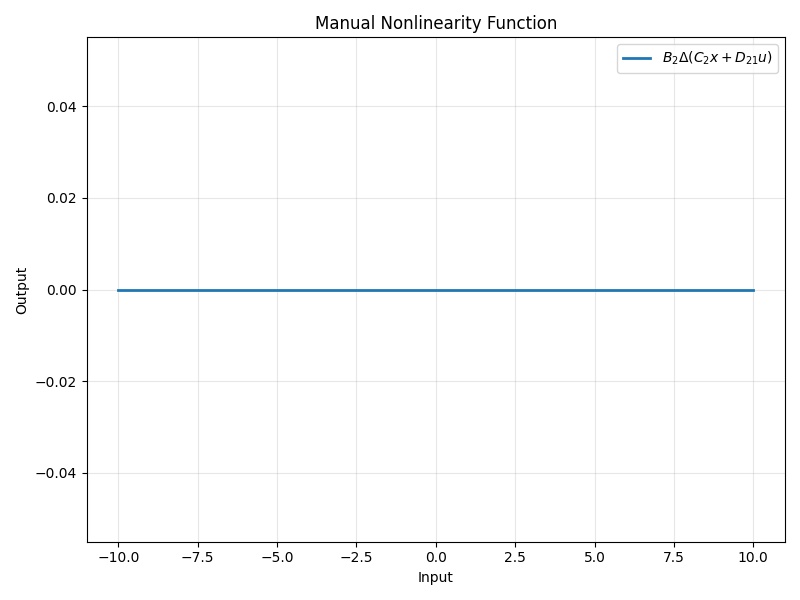

In [12]:
TS      = 0.05  # sample time [s]

# Plot the nonlinearity function
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(xs, y_hats,  linewidth=2, markersize=6, label=r'$B_2 \Delta(C_2 x + D_{21} u)$')
# ax.plot(xs, y_hats_fitted,  linewidth=2, markersize=6, label=r'$B_2 \Delta(C_2 x + D_{21} u)$ (Fitted)')

# ax.plot(xs, TS*xs**3, '--', linewidth=2, label=r'$x^3$')
# ax.plot(xs, -TS*xs**3, '--', linewidth=2, label=r'$x^3$')
ax.set_xlabel('Input')
ax.set_ylabel('Output')
ax.set_title('Manual Nonlinearity Function')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [73]:
Y = 1/(s**2 * C @ P @ C.T)
y_bound = 1/np.sqrt(Y)
print(f"Y: {Y}, y_bound: {y_bound}")
normalizer.inverse_transform_outputs(y_bound)

Y: [[0.05064579]], y_bound: [[4.44353211]]


array([[[0.45453236]]])

In [74]:
import cvxpy as cp

In [75]:
Y = cp.Variable((ne,ne))
ctr = [-C.T @ Y @ C + np.linalg.inv(P) /s**2 >> 0]
obj = cp.Maximize(cp.trace(Y))
prob = cp.Problem(obj, ctr)
prob.solve(solver=cp.MOSEK, verbose=False)
print(f'Problem status: {prob.status}')
print(f'Minimal output reachable set given by E(Y) with Y: {Y.value}')
y_bound = 1/np.sqrt(Y.value)
print(f"Y: {Y}, y_bound: {y_bound}")
normalizer.inverse_transform_outputs(y_bound)

Problem status: optimal
Minimal output reachable set given by E(Y) with Y: [[0.05064579]]
Y: var6823, y_bound: [[4.44353212]]


array([[[0.45453236]]])

check if model satisfies global stability constraints

In [77]:
# calculate the output reachable set
P = cp.Variable((nx, nx), symmetric=True)
# L = np.zeros((nz, nx))
L = cp.Variable((nz, nx))
m = cp.Variable((nz, 1))
M = cp.diag(m)

eps = 1e-6
constraints = []

# stability constraints
F = cp.bmat(
    [
        [-(alpha**2) * P, np.zeros((nx, nd)), P @ C2.T + L.T, P @ A.T],
        [np.zeros((nd, nx)), -np.eye(nd), D21.T, B.T],
        [C2 @ P + L, D21, -2 * M, M @ B2.T],
        [A @ P, B, B2 @ M, -P],
    ]
)
nF = F.shape[0]
constraints.append(F << -eps * np.eye(nF))

# constraints for generalized sector condition
G = []
for i in range(nz):
    li = L[i, :].reshape((1, -1), order="C")
    G_i = cp.bmat([[1/s**2, li], [li.T, P]])
    G.append(G_i)
    constraints.append(G_i >> eps * np.eye(nx + 1))

objective = cp.Minimize([None])
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.MOSEK, verbose=False, accept_unknown=True)
print(f'Problem status: {problem.status}')

# sanity check
print('max eigenvalue of F:', np.max(np.real(np.linalg.eig(F.value)[0])))
for i, G_i in enumerate(G):
    eigvals = np.linalg.eig(G_i.value)[0]
    min_eigval = np.min(np.real(eigvals))
    print(f"min eigenvalue of G[{i}]: {min_eigval}")


Problem status: optimal
max eigenvalue of F: -0.0005891331869202171
min eigenvalue of G[0]: 0.14363605676193497
min eigenvalue of G[1]: 0.07284738654811264
min eigenvalue of G[2]: 0.10408918077945897
min eigenvalue of G[3]: 0.00989798265877405
min eigenvalue of G[4]: 0.13182316649191564
min eigenvalue of G[5]: 0.13432453514200182
min eigenvalue of G[6]: 0.14369138721933422
min eigenvalue of G[7]: 0.12989593566519725
min eigenvalue of G[8]: 0.11669617084007361
min eigenvalue of G[9]: 0.10994689016642001
min eigenvalue of G[10]: 0.0642867109645253
min eigenvalue of G[11]: 0.14068965401716055
min eigenvalue of G[12]: 0.036352888206162955
min eigenvalue of G[13]: 0.11846121029621148
min eigenvalue of G[14]: 0.0627278993080726
min eigenvalue of G[15]: 0.14212044029691012
min eigenvalue of G[16]: 0.11481883366059994
min eigenvalue of G[17]: 0.1436726633323228
min eigenvalue of G[18]: 0.1138983122089506
min eigenvalue of G[19]: 0.13784408465262707
min eigenvalue of G[20]: 0.14334587121698739


In [19]:

# calculate the output reachable set
P = cp.Variable((nx, nx), symmetric=True)
L = cp.Variable((nz, nx))
# L = np.zeros((nz, nx))  # fix L to zero for convexity
m = cp.Variable((nz, 1))
M = cp.diag(m)

eps = 1e-6
constraints = []

# stability constraints
F = cp.bmat(
    [
        [-(alpha**2) * P, np.zeros((nx, nd)), P @ C2.T + L.T, P @ A.T],
        [np.zeros((nd, nx)), -np.eye(nd), D21.T, B.T],
        [C2 @ P + L, D21, -2 * M, M @ B2.T],
        [A @ P, B, B2 @ M, -P],
    ]
)
nF = F.shape[0]
constraints.append(F << -eps * np.eye(nF))

# constraints for generalized sector condition
for i in range(nz):
    li = L[i, :].reshape((1, -1), order="C")
    locality_lmi = cp.bmat([[1/s**2, li], [li.T, P]])
    constraints.append(locality_lmi >> eps * np.eye(nx + 1))

# output reachable set constraints
Y_tilde = cp.Variable((ne,ne))
# constraints.append(cp.bmat([[P/s**2, (C @ P).T], [C @ P, Y_tilde]]) >> eps * np.eye(nx + ne))
constraints.append(cp.bmat([
    [Y_tilde, C @ P, D],
    [(C@P).T, P/s**2, np.zeros((nx,nd))],
    [D.T, np.zeros((nd,nx)), 1/delta.reshape((1,1))**2]
]) >> eps * np.eye(nx+ne+nd))

objective = cp.Minimize(cp.trace(Y_tilde))
problem = cp.Problem(objective, constraints )
problem.solve(solver=cp.MOSEK, verbose=True, accept_unknown=True)
print(f'Problem status: {problem.status}')
Y = 1/Y_tilde.value
print(f'Minimal output reachable set given by E(Y) with Y: {1/Y_tilde.value}')

(CVXPY) May 05 10:10:36 PM: Your problem has 65 variables, 821 constraints, and 0 parameters.
(CVXPY) May 05 10:10:36 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 05 10:10:36 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 05 10:10:36 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 05 10:10:36 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) May 05 10:10:36 PM: Compiling problem (target solver=MOSEK).
(CVXPY) May 05 10:10:36 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> MOSEK
(CVXPY) May 05 10:10:36 PM: Applying reduction Dcp2Cone
(CVXPY) May 05 10:10:36 PM: Applying reduction CvxAttr2Constr
(CVXPY) May 05 10:10:36 PM: Applying reduction ConeMatrixStuffing
(CVXPY) May 05 10:10:36 PM: Applying reduction MOSEK


                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) May 05 10:10:37 PM: Finished problem compilation (took 2.035e-01 seconds).
(CVXPY) May 05 10:10:37 PM: Invoking solver MOSEK  to obtain a solution.
(CVXPY) May 05 10:10:37 PM: Problem
(CVXPY) May 05 10:10:37 PM:   Name                   :                 
(CVXPY) May 05 10:10:37 PM:   Objective sense        : maximize        
(CVXPY) May 05 10:10:37 PM:   Type                   : CONIC (conic optimization problem)
(CVXPY) May 05 10:10:37 PM:   Constraints            : 64              
(CVXPY) May 05 10:10:37 PM:   Affine conic cons.     : 0               
(CVXPY) May 05 10:10:37 PM:   Disjunctive cons.      : 0               
(CVXPY) May 05 10:10:37 PM:   Cones                  : 0               
(CVXPY) May 05 10:10:37 PM:   Scalar variables       : 0               
(CVXPY) May 05 10:10:37 PM:   Matrix variables       : 22 (scalarized: 455)
(CVXPY) May 05 10:10:37 PM:   Integer variables      : 0               
(CVXPY) May 05 10:10:37 PM: 
(CVXPY) May 05 10:10:37 PM: Optimizer

-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Problem status: optimal_inaccurate
Minimal output reachable set given by E(Y) with Y: [[8928.38315218]]


In [14]:
y_bound_n = 1/np.sqrt(Y)
print(f"Y: {Y}, y_bound: {y_bound_n}")
y_bound = normalizer.inverse_transform_outputs(y_bound_n)
print(f'Output of model is guranteed to be in the range [-{y_bound.squeeze():.4f}, {y_bound.squeeze():.4f}] mV')

Y: [[0.97491666]], y_bound: [[1.01278265]]
Output of model is guranteed to be in the range [-0.1598, 0.1598] mV


In [43]:
np.linalg.norm(L.value)

0.10204843163362688

In [7]:
# from https://github.com/MaartenSchoukens/nonlinear_benchmarks/blob/master/submission_examples/silverbox.py

import nonlinear_benchmarks

# Load data: 
# Keep this part fixed, though you can split the train set further in a train and validation set. 
# Do not use the test set to make any decision about the model (parameters, hyperparameters, structure, ...)
train, test = nonlinear_benchmarks.Silverbox()
test_multisine, test_arrow_full, test_arrow_no_extrapolation = test
n = test_multisine.state_initialization_window_length

In [8]:
import matplotlib.pyplot as plt
%matplotlib widget

In [9]:

u = test_multisine.u[n:]  # (N, nd)
y = test_multisine.y[n:]  # (N, ne)

u = u.reshape(-1, 1)

N, nd = u.shape

# Convert to torch tensors with batch dimension
u_torch = torch.tensor(u, dtype=torch.float32).unsqueeze(0)  # (1, N, nd)

# Normalize inputs if normalizer exists
if normalizer is not None:
    u_torch = normalizer.transform_inputs(u_torch)
    
# Run model (x0=None will use random initialization)
with torch.no_grad():
    y_pred_torch = model(u_torch, x0=None)  # (1, N, ne)
    
# Denormalize outputs if normalizer exists
if normalizer is not None:
    y_pred_torch = normalizer.inverse_transform_outputs(y_pred_torch)
    
# Convert back to numpy and remove batch dimension
y_pred = y_pred_torch.cpu().numpy().squeeze()  # (N,) or (N, ne)


    

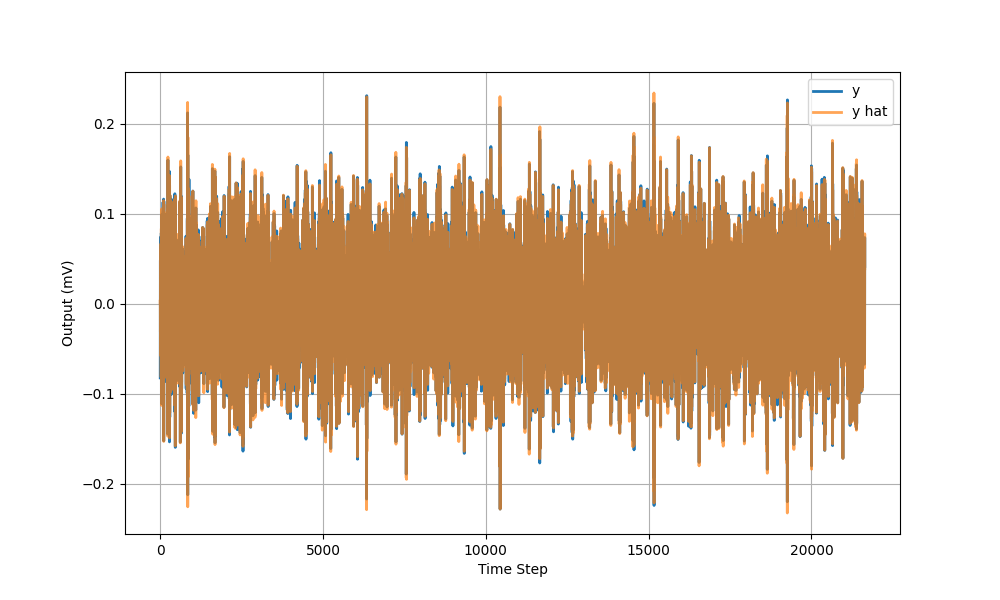

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(y, label="y", linewidth=2)
plt.plot(y_pred, label="y hat", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Output (mV)")
plt.legend()
plt.grid()
plt.show()  



In [10]:
y_hat, (x, w) = model(u_torch, x0=None, return_state=True)  # (1, N, ne)

In [127]:
P

array([[  8212.00882837,    879.38408448,  -3590.40388779,
          -157.73001877,   5008.35764961,   2093.73008733,
         -4350.30098064,  -6171.73882055,    213.13446985,
          7769.77966935],
       [   879.38408448,   6767.93830145,   2906.48745633,
         -7511.55149302,  -2257.78987767,  -1645.2208177 ,
          2529.8808001 ,  -3898.39064692,   8112.12462498,
          5456.15380279],
       [ -3590.40388779,   2906.48745633,  16896.85008696,
          2887.7992072 , -13005.64735656,   -691.44845473,
         -1103.95689944,  -4682.9232929 ,  10466.36599261,
         -9854.43685109],
       [  -157.73001877,  -7511.55149302,   2887.7992072 ,
         13194.27674537,  -2669.43637148,   4665.48284176,
         -8388.26569549,  -2838.56124522,  -7495.64901891,
         -7166.24361547],
       [  5008.35764961,  -2257.78987767, -13005.64735656,
         -2669.43637148,  12657.64399683,   -935.77541726,
          2795.1524678 ,   5498.85148903,  -7005.140575  ,
          7

In [132]:
L = L.value
P = P.value

In [133]:
print(f'Norm of P: {np.linalg.norm(P)}')
print(f'Norm of P^(-1)/s^2: {np.linalg.norm(np.linalg.inv(P)/s**2)}')
print(f'Norm of L: {np.linalg.norm(L)}')

print(f'Norm of A: {np.linalg.norm(A)}')
print(f'Norm of B: {np.linalg.norm(B)}')
print(f'Norm of B2: {np.linalg.norm(B2)}')

print(f'Norm of C: {np.linalg.norm(C)}')
print(f'Norm of D: {np.linalg.norm(D)}')
print(f'Norm of D12: {np.linalg.norm(D12)}')

print(f'Norm of C2: {np.linalg.norm(C2)}')
print(f'Norm of D21: {np.linalg.norm(D21)}')



Norm of P: 69651.91927575783
Norm of P^(-1)/s^2: 0.016281890115075127
Norm of L: 0.22178171893642545
Norm of A: 1.7746792950042696
Norm of B: 0.24608408433003667
Norm of B2: 0.10181813243818312
Norm of C: 1.3062178891080531
Norm of D: 0.015077127318881502
Norm of D12: 2.3644182789127153e-86
Norm of C2: 0.04318177251075299
Norm of D21: 0.011794654832819227


[[0.]]
[[0.06569237]]
[[-0.15190696]]
[[-0.45370574]]
[[-0.58334276]]
[[-0.51922404]]
[[-0.04218027]]
[[0.76079704]]
[[1.06379503]]
[[0.53992888]]
max a: 0.0000


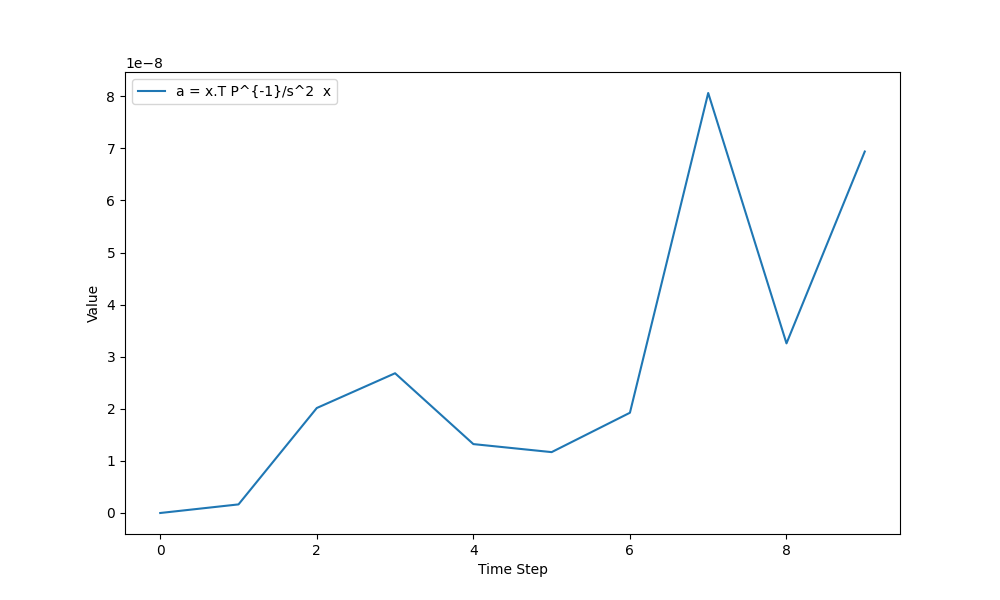

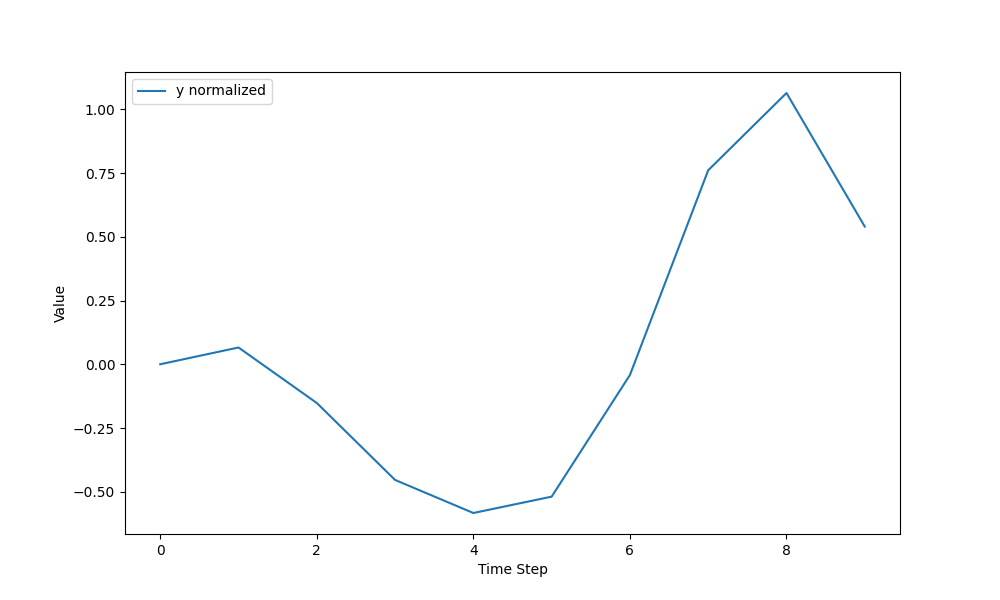

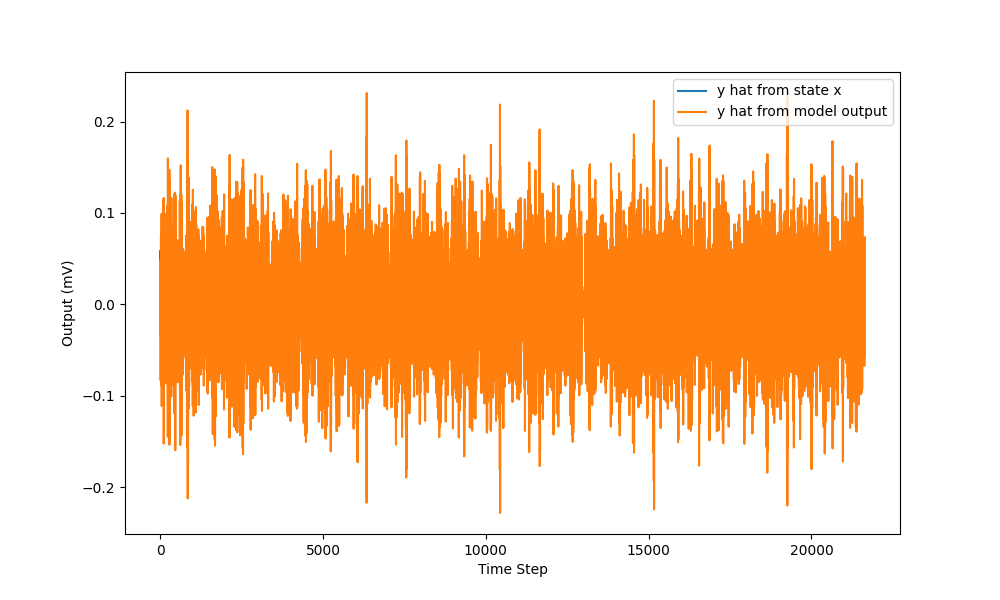

In [22]:
a_list = []
b_list = []
y_hat2 = []
for x_i in x[0,:10,:,:]:
    
    x_i = x_i.cpu().detach().numpy()
    print(C @ x_i)
    # print(x_i.T @ P.value @ x_i)
    a_list.append(x_i.T @ np.linalg.inv(P)/s**2 @ x_i)
    # b_list.append(x_i.T @ C.T @ Y @ C @ x_i)
    y_hat2.append(C @ x_i)

a = np.array(a_list).squeeze()
# b = np.array(b_list).squeeze()
y_hat2 = np.array(y_hat2).squeeze()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a, label="a = x.T P^{-1}/s^2  x")
# ax.plot(b, label="b = x.T @ C.T @ Y @ C @ x")
ax.set_xlabel("Time Step")
ax.set_ylabel("Value")
ax.legend()
print(f'max a: {np.max(a):.4f}')
# print(f'max b: {np.max(b):.4f}')

# all(b <= a)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(y_hat2.squeeze(), label="y normalized")
ax.set_xlabel("Time Step")
ax.set_ylabel("Value")
ax.legend()


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(normalizer.inverse_transform_outputs(y_hat2).squeeze(), label="y hat from state x")
ax.plot(y.squeeze(), label="y hat from model output")
ax.set_xlabel("Time Step")
ax.set_ylabel("Output (mV)")
ax.legend() 

In [ ]:
normalizer.inverse_transform_outputs(y_hat2).shape

array([[ 8.62079790e-02,  5.22716324e-03, -3.24556755e-07,
        -1.94034759e-04,  1.16467827e-04,  1.81512779e-03,
        -2.47031568e-06,  2.68622355e-04, -1.73363719e-05,
        -4.32106715e-07],
       [ 5.22716324e-03,  3.16945553e-04, -1.96792821e-08,
        -1.17651681e-05,  7.06194889e-06,  1.10059061e-04,
        -1.49785942e-07,  1.62877371e-05, -1.05117933e-06,
        -2.62005021e-08],
       [-3.24556755e-07, -1.96792821e-08,  1.22189487e-12,
         7.30504214e-10, -4.38479365e-10, -6.83361322e-09,
         9.30027188e-12, -1.01131242e-09,  6.52681653e-11,
         1.62680015e-12],
       [-1.94034759e-04, -1.17651681e-05,  7.30504214e-10,
         4.36728575e-07, -2.62142866e-07, -4.08544415e-06,
         5.56012465e-09, -6.04608467e-07,  3.90202716e-08,
         9.72574968e-10],
       [ 1.16467827e-04,  7.06194889e-06, -4.38479365e-10,
        -2.62142866e-07,  1.57349178e-07,  2.45225547e-06,
        -3.33742076e-09,  3.62911441e-07, -2.34216088e-08,
        -5.

In [73]:
C

array([[ 2.91455412e+02,  1.76722043e+01, -1.09727457e-03,
        -6.56000539e-01,  3.93759125e-01,  6.13665722e+00,
        -8.35174288e-03,  9.08169290e-01, -5.86115053e-02,
        -1.46088381e-03]])